<a href="https://colab.research.google.com/github/iamanzo1990/analysis-everpeak/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

**Objetivo**: evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajaremos con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Debemos **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis nos permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.




---
## 🧩 Paso 1: Cargar y explorar
  
En esta etapa, validaremos que los archivos se carguen correctamente, conocer sus columnas y tipos de datos, y detectar posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.




In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv ('/datasets/users_latam.csv')
usage = pd.read_csv ('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.


In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.



In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Diagnóstico**

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?


En users:

      city 11% y churn_date 88%
  
En usage:

      date 1.2%; duration 55% y length 44%
  
- Acción a tomar

En users:

    city - Ignorar

    churn_date - Eliminar
  
En usage:

    date - Ignorar

    duration - Ignorar

    length - Ignorar


Se ignorar la mayoría de las columnas donde hay faltantes ya que la proporción es elevada y puede influir en su estadistica si decidimos imputar, con excepción de "date", ya que es un dato el cual no es posible conocer y por lo tanto imputar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.



In [ ]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un dato en el cual no es posible aplicarle formulas, ya que solamente es una cifra de identificación.
- La columna `age` se puede percibir que existen "sentinels" en los valores minimos más bajos (outliers) y por lo tanto eso provoca que la media se encuentra algo alejada de la mediana.

In [ ]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son datos en los cuales no es posible aplicarles formulas, ya que solamente son cifras de identificación.
- Las columnas 'duration' y 'length' vemos que existen outliers en los valores máximos más altos, principalmente en "length".

In [ ]:
# explorar columnas categóricas de users
users[['city', 'plan']].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` cuenta con algunos valores faltantes, 7 valores, y la ciudad más frecuente es "Bogotá".
- La columna `plan` está completa, cuenta unicamento con 2 valores, siendo el más frecuente "Básico".

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` se encuentra completa, siendo "text" el tipo más frecuente superando a "calls".


---
✍️ **Diagnóstico**

**Valores inválidos o sentinels**  
- ¿En qué columnas encontramos valores inválidos o sentinels?

      En la columna "age" (-999.000000), y "city" (?)
    
- ¿Qué acción se tomaría?

      Reemplazar los valores (?) de "city" por NaN, y los valores (-999.000000) en "age" reemplazarlos por la mediana.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.



In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se puede apreciar que hay 1330 datos para el año 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, se puede observar de que existen casi 40000 registros para el año 2024.
Basaremos el análisis en estas fechas.

✍️ **Diagnóstico**

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

        Como se están tomando en cuenta los datos registrados hasta el año 2024, se tendrían que depurar los registros de los años distintos a este.

- Tratamiento

        Se eliminarían los registros de los años 2026, 2022 y 2023.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.



In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2025, 'reg_date'] = np.nan

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.



In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

Diagnostico de nulos en `duration` y `length`

    Aquí podemos observar que la relación es directamente proporcional entre la columna 'duration' y los nulos en el elemento "text" de la columna 'type', y al mismo tiempo entre la columna 'lenght' y los nulos que hay en el elemento "call" de la columna 'type'.

    Por lo tanto se considera valores ausentes de tipo MAR, ya que los nulos tiene relación con el 'type' del Dataset. Los nulos al representar cerca del 50%, la mejor opción es dejarlos como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.



In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby('user_id').agg({'is_text':'sum', 'is_call':'sum', 'duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios

user_profile = pd.merge(usage_agg, users, on=['user_id'], how='left')
user_profile.head(5)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.



In [ ]:
# Resumen estadístico de las columnas numéricas
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Distribución porcentual del tipo de plan
print(users['plan'].value_counts(normalize=True))

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.



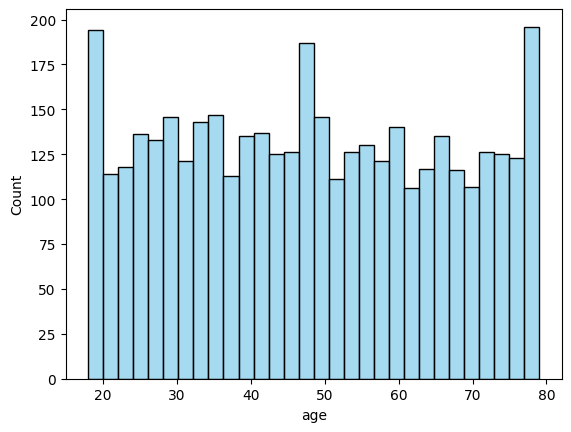

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(users['age'], bins=30, color='skyblue')
plt.show()


💡Insights:
- Distribución simétrica, no existe un sesgo tan notorio ya que la media es muy similar a la mediana.

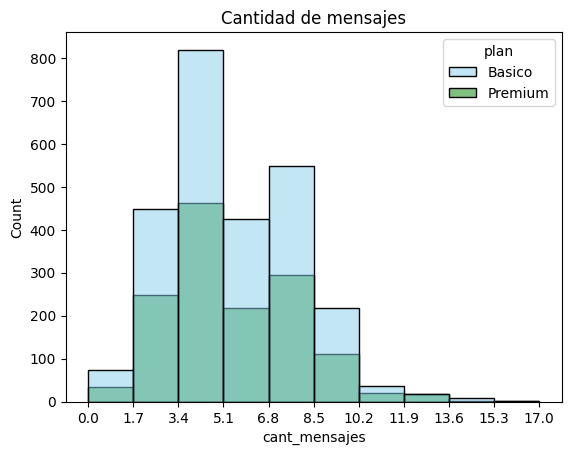

In [ ]:
# Histograma para visualizar la cant_mensajes

counts, bin_edges = np.histogram(user_profile['cant_mensajes'], bins=10)
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue','green'])
plt.xticks(bin_edges)
plt.title ("Cantidad de mensajes")
plt.show()

💡Insights:
- Distribución sesgada a la derecha del gráfico. La distribución tiende a estar equilibrada entre la proporción de personas que envían mensajes ya sea del plan básico o premium.

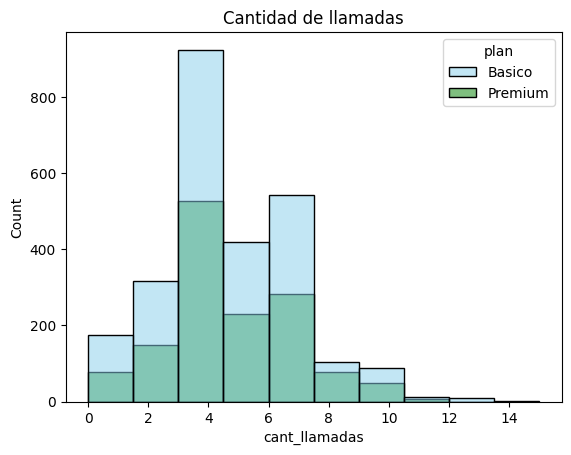

In [ ]:
# Histograma para visualizar la cant_llamadas
counts, bin_edges = np.histogram(user_profile['cant_llamadas'], bins=10)
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue','green'])
plt.title ("Cantidad de llamadas")
plt.show()

💡Insights:
- Distribución sesgada a la derecha del gráfico. Aquí se nota ligeramente que hay más proporción de llamadas hechas por personas con el plan premium que con el básico.

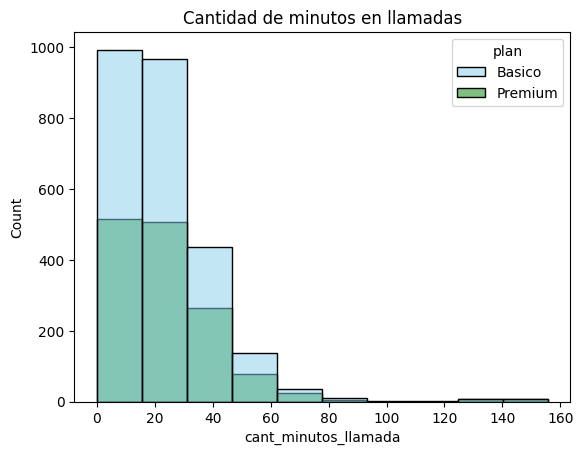

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
counts, bin_edges = np.histogram(user_profile['cant_minutos_llamada'], bins=10)
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue','green'])
plt.title ("Cantidad de minutos en llamadas")
plt.show()

💡Insights:
- Distribución sesgada a la derecha del gráfico. Aquí notamos de manera singular que los de plan premium suelen realizar llamadas más largas. Mientras más es la duración,  más es la cantidad de personas con el plan premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.



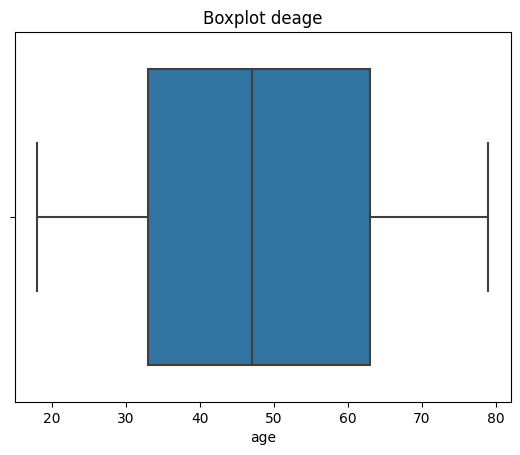

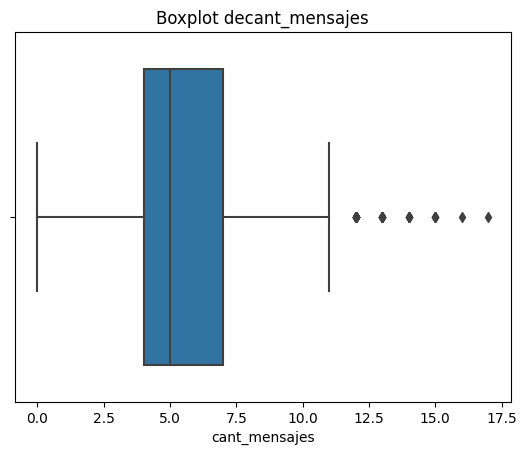

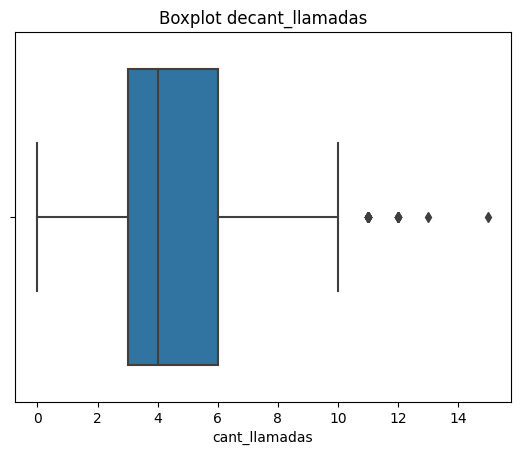

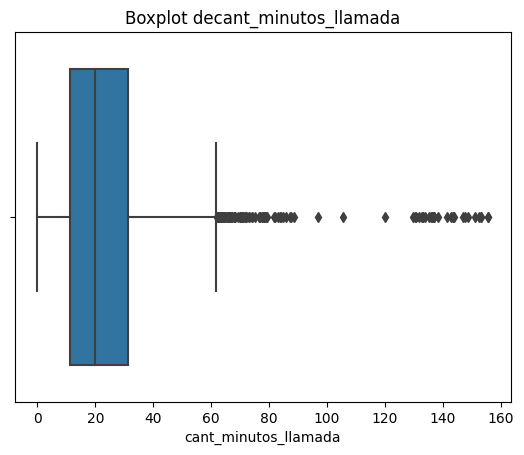

<function box_plot at 0x7f9bdd6d5820>


In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

def box_plot(user_profile, columnas_numericas):
    for col in columnas_numericas:
        sns.boxplot(data=user_profile, x=col)
        plt.title("Boxplot de"+ col)
        plt.show()
    return user_profile

box_plot(user_profile, columnas_numericas)

print(box_plot)

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Presenta outliers hacia la izquierda del gráfico
- cant_llamadas: Presenta outliers hacia la izquierda del gráfico
- cant_minutos_llamada: Presenta outliers hacia la izquierda del gráfico

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

def limites(tabla, columnas_limites):
    for col in columnas_limites:
        Q1 = tabla[col].quantile(0.25)
        Q3 = tabla[col].quantile(0.75)
    return Q1, Q3

tabla = user_profile
Q1, Q3 = limites(user_profile, columnas_limites)

IQR = Q3 - Q1

# Calcular limite inferior
lower = Q1 - 1.5 * IQR
print("Limite inferior", lower)


# Calcular limite superior
upper = Q1 + 1.5 * IQR
print("Limite superior", upper)


Limite inferior -19.322500000000005
Limite superior 41.5625


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?

  Mantenerlos, ya que sus minimos y máximos no superan los limites inferior y superior
  
- cant_llamadas: mantener o no outliers, porqué?

  Mantenerlos, ya que sus minimos y máximos no superan los limites inferior y superior


- cant_minutos_llamada: mantener o no outliers, porqué?

  Mantenerlos, debido a que a pesar de estar fuera de lo común, si cabe la posibilidad de que una persona realice llamada con esa cantidad de tiempo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.



In [ ]:
# Crear columna grupo_uso
def clasificacion_uso (row):
    calls = row['cant_llamadas']
    messages = row['cant_mensajes']

    if pd.isna(calls) or pd.isna(messages):
        return "Error de datos"

    if calls and messages < 5:
        return 'Bajo uso'
    elif calls and messages < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificacion_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Uso medio
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.



In [ ]:
# Crear columna grupo_edad
def clasificacion_edad (row):
    edad = row['age']

    if pd.isna(edad):
        return "Error de datos"

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificacion_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Uso medio,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.



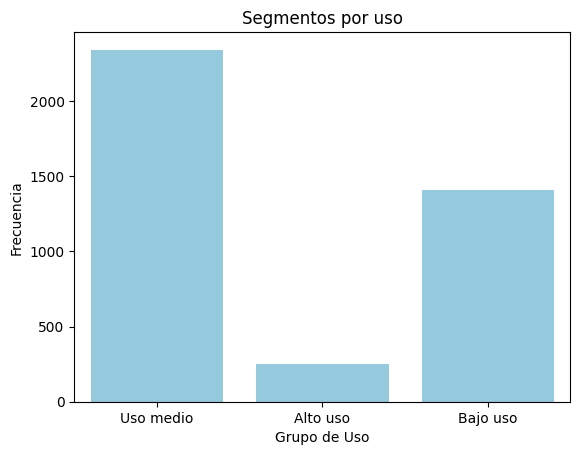

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(user_profile['grupo_uso'], color = "skyblue")
plt.xlabel('Grupo de Uso')
plt.ylabel('Frecuencia')
plt.title('Segmentos por uso')
plt.show()


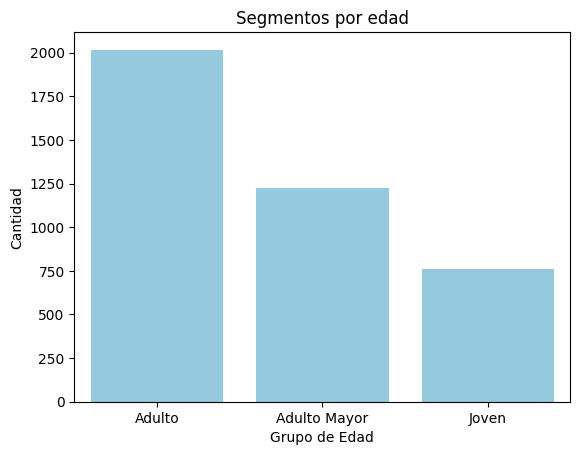

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(user_profile['grupo_edad'], color = "skyblue")
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad')
plt.title('Segmentos por edad')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

        En los Datasets hayamos problemas de sentinels, valores nulos, y outliers que podía hacer imprecisas las estadisticas. Algunos casos especificos son los siguientes:

        - Nulos en las columnas city 11%, duration 55% y lenght 44%. En estos casos se decidió ignoralos para no que no influenciaran en las estadisticas al ser una proporción grande.
        - Además se halló sentinels en la columna age (-999.000000) los cuales se reemplazó por la mediana, y valores invalidos en city (?) y en reg_date (2026) los cuales se reemplazaron por NaN.
        - Finalmente outliers en cantidad de mensajes, llamadas y minutos que decidimos mantener por la poca injerencia que ejercian en los datos y su factibilidad como en el caso de la cantidad de minutos en llamadas, el cual su valor máximo (155.69) superaba el limite superior (41.56).


- ¿Qué segmentos de clientes identificamos y cómo se comportan según su edad y nivel de uso?

        Se identificó 3 segmentos de clientes por edades (Adulto, Adulto Mayor y Joven). Los Adultos es el grupo que tiene el mayor monto de uso, y a la vez el mayor nivel de uso es el medio. El segmento con menor cantidad de uso es el Joven.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

        El segmento Adulto ya que es el que mayor consumo tiene.
        
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

        Se encontró un patrón de uso extremo en los mensajes y llamadas pero no tan considerable como para corregirlos. Solamente en la cantidad de minutos en llamada es donde el limite intercuartilico superior fue rebasado.
  
        Las implicaciones para el negocio serían que sesgarían las estadisticas. Sin embargo, es factible que los clientes realicen llamadas duraderas.

- ¿Qué recomendaciones haríamos para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

        La estrategia recomendada es proteger y potenciar al segmento Adulto con planes premium y familiares, dar planes simples de llamadas a los Adultos mayores, y atraer a los Jóvenes con opciones flexibles y económicas para impulsar su consumo. Los usuarios de uso extremo en llamadas se atenderían con un plan específico de alto volumen. Todo ello se apoyaría en mejorar los datos para afinar la segmentación en el futuro.



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- 11% de datos nulos en la calumna "city"
- 55% de datos nulos detectados en la columna "duration"
- 44% de detos nulos detectados en la columna "lenght"
- Sentinels (-999.000000) en la columna "Age"
- Sentinels (?) en la columna "city"
- Registro de años fuera de contexto (2026) en la columna "reg_date"
- Valores nulos correlacionados entre el elemento "text" de la columna "type" y "duration"
- Valores nulos correlacionados entre el elemento "call" de la columna "type"  y "lenght"
- Outliers principalmente en la columna "cant_minutos_llamada"


🔍 **Segmentos por Edad**
- Adulto
- Adulto Mayor
- Joven


📊 **Segmentos por Nivel de Uso**
- Uso medio
- Alto uso
- Bajo uso


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Fortalecer el segmento principal Adulto. Conviene cuidar a los clientes adultos con paquetes de gama alta y esquemas familiares que los mantengan y aumenten su valor.
-  Adaptar la oferta a los grupos de mayor edad, se les ofrecería una propuesta sencilla centrada en la telefonía, sin complicaciones.
-  Captar a los más jóvenes lanzando alternativas accesibles y ajustables que estimulen un mayor uso del servicio.
-  Buscar una solución a quienes llaman en exceso. Quienes realizen un volumen muy alto de llamadas contarían con un plan hecho a su medida.
-  Mejorar la calidad de la información como base de todo lo demás. Reunir y depurar mejores datos permitirá dividir a la clientela con más precisión en el futuro y ajustar las ofertas con mayor acierto.